In [3]:
from qiskit import __version__
from rich.jupyter import display

print(__version__)

2.4.2


In [4]:
#!pip install qiskit
#!pip install jupyter
#!pip install sympy
#!pip install matplotlib
#!pip install pylatexenc

In [5]:
import numpy as np

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0 / 2 + ket1 / 2)

[[0.5]
 [0.5]]


In [6]:
M1= np.array ([ [1,1],[0,1]])
M2= np.array ( [[1,0],[0,1]])
M =( (M1 / 2) + (M2 / 2))
print(M)

[[1.  0.5]
 [0.  1. ]]


Matrix multiplication, including matrix-vector multiplication as a special case, can be performed using the @ operator

In [7]:
print ( M1 @ ket0)
print( M2 @ ket1)
print( M @ M)

[[1]
 [0]]
[[0]
 [1]]
[[1. 1.]
 [0. 1.]]


This output formatting leaves something to be desired, visually speaking. One solution, for situations that demand something prettier, is to use thearray_to_latex function in Qiskit, from the qiskit.visualization module. Note that, in the code that follows, we're using Python's generic display function. In contrast, the specific behavior of print may depending on what is printed, such as it does for arrays defined by NumPy.

The *sympy* library is required to visualise the latex

*Note: display got overwritten by your own code (e.g. a def display(...) somewhere), so from IPython.display import display re-binds the name back to the real Jupyter display function.*

In [8]:
import sympy
print(sympy.__version__)

1.14.0


In [9]:
from IPython.display import display
from qiskit.visualization import array_to_latex

display(array_to_latex(M1 @ ket1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

TheStatevector class in Qiskit provides functionality for defining and manipulating quantum state vectors. In the code that follows, the Statevector class is imported and a few vectors are defined. (We're also importing the sqrt function from the NumPy library to compute a square root. This function could, alternatively, be called as np.sqrt provided that NumPy has already been imported, as it has above; this is merely a different way to import and use this specific function alone.)

In [10]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1+ 2.0j) /3, -2/3 ])
w = Statevector([ 1/3, 2/3])
print(u)
print(v)
print(w)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Statevector([ 0.33333333+0.66666667j, -0.66666667+0.j        ],
            dims=(2,))
Statevector([0.33333333+0.j, 0.66666667+0.j],
            dims=(2,))


The Statevector class includes a draw method for displaying state vectors in a variety of ways, including text for plain text, latex for rendered LaTeX, and latex_source for LaTeX code, which can be handy for cutting and pasting into documents. (Use print rather than display to show LaTeX code for best results.)


In [11]:
display(u.draw("text"))
display(u.draw("latex"))
display(u.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

'\\frac{\\sqrt{2}}{2} |0\\rangle+\\frac{\\sqrt{2}}{2} |1\\rangle'

The Statevector class also includes the is_valid method, which checks to see if a given vector is a valid quantum state vector (in other words, that it has Euclidean norm equal to 1):

In [12]:
display(u.is_valid())
display(w.is_valid())

True

False

Next we will see one way that measurements of quantum states can be simulated in Qiskit, using the measure method from the Statevector class. Let's use the same qubit state vector v defined previously.

In [13]:
display(v.draw("latex"))
display(w.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Running the measure method simulates a standard basis measurement. It returns the outcome of that measurement, plus the new quantum state vector of the system after the measurement. (Here we're using Python's print function with an f prefix for formatted printing with embedded expressions.)

## Measurement Collapses the State

Measuring a qubit forces it to "pick" a definite outcome from a superposition —
like a spinning coin landing on heads or tails. Before measurement, it can be a
mix of |0⟩ and |1⟩; after measurement, it's only ever one or the other.

### What `v.measure()` does:
1. **Picks an outcome randomly**, weighted by the qubit's amplitudes.
   - P(0) = |amplitude of |0⟩|²
   - P(1) = |amplitude of |1⟩|²
2. **Collapses the state** to match that outcome — the other component
   is discarded entirely.
3. **Renormalizes** the surviving amplitude so the new state still has
   total probability = 1 (a valid quantum state).

### Example
State: v = (1/3 + 2i/3)|0⟩ + (2/3)|1⟩

- P(0) = |1/3 + 2i/3|² = 5/9  (~56%)
- P(1) = |2/3|² = 4/9         (~44%)

Measured outcome: **0**

Post-measurement state (renormalized):
(√5/5 + 2√5i/5)|0⟩

→ Same "direction" as the original |0⟩ component, just rescaled to length 1.

### Key takeaway
Measurement is **probabilistic** (you can't predict which outcome in advance)
and **destructive** (the superposition is gone afterward — you only see one
collapsed result).

In [14]:
outcome, state = v.measure()
print(f"Measured: {outcome}\n Post Measurement state:")
display(state.draw("latex"))

Measured: 0
 Post Measurement state:


<IPython.core.display.Latex object>

Statevector also comes with a sample_counts method that allows for the simulation of any number of measurements on the system, each time starting with a fresh copy of the state. For example, the following code shows the outcome of measuring the vector v
1000
1000 times, which (with high probability) results in the outcome
0
0 approximately
5
5 out of every
9
9 times (or about
556
556 of the
1000
1000 trials) and the outcome
1
1 approximately
4
4 out of every
9
9 times (or about
444
444 out of the
1000
1000 trials). The code that follows also demonstrates the plot_histogram function from the qiskit.visualization module for visualizing the results.

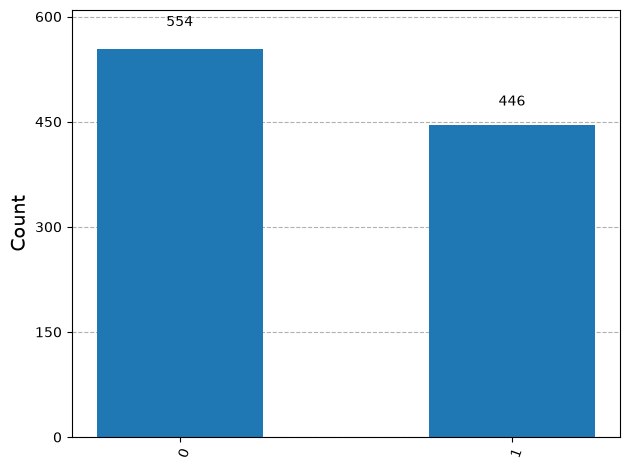

In [15]:
from qiskit.visualization import plot_histogram
statistics = v.sample_counts(1000)
plot_histogram(statistics)

## Operators and the `evolve` Method

### The `Operator` Class
Qiskit lets you define unitary operations (quantum gates as matrices) using
the `Operator` class. It works just like `Statevector` and also has a
`.draw("latex")` method to display the matrix nicely.

```python
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1/sqrt(2), 1/sqrt(2)], [1/sqrt(2), -1/sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j)/sqrt(2)]])
```

These are common single-qubit gates:
- **Y** — Pauli-Y gate
- **H** — Hadamard gate (creates superposition)
- **S** — phase gate (quarter turn)
- **T** — phase gate (eighth turn)

### Applying an Operator to a State: `evolve()`

To apply a gate to a quantum state, use `.evolve()` — this is just
matrix multiplication: `new_state = Operator @ old_state`, but written in
a more readable, chainable way.

```python
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)
```

Each line takes the **current** state `v` and transforms it by applying
the next gate — like sending the qubit through a sequence of gates in a
circuit, one at a time, and updating `v` after each step.

### Key takeaway
- `Operator` = a gate (a matrix).
- `Statevector` = a qubit's state (a vector).
- `.evolve(gate)` = apply that gate to the state, returning the new state.

This is functionally identical to manually computing `gate_matrix @ state_vector`,
but reads more like an actual quantum circuit, applying gates one after another.

In [16]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [17]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>